In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.interpolate import UnivariateSpline

import pandas as pd
import json

import SR_lib as sr


In [163]:
def load_sr_metrics(file_path):
    """
    Load SR metrics arrays from a JSON file.
    Returns the SR metrics as numpy arrays.
    """
    with open(file_path, "r") as jf:
        data = json.load(jf)

    sd_crt = np.array(data["sd_crt"])
    bw_crt = np.array(data["bw_crt"])
    Dext_delF = np.array(data["Dext_delF"])
    Dext_delF_crt = np.array(data["Dext_delF_crt"])
    PSR = np.array(data["PSR"])
    NF = np.array(data["NF"])
    SNR = np.array(data["SNR"])
    COV = np.array(data["COV"])

    return sd_crt, bw_crt, Dext_delF, Dext_delF_crt, PSR, NF, SNR, COV

In [164]:
## Read the Parse file
params_path = 'sim_ktpred_1/parameters.txt'  # Parse input file
params = sr.read_simulation_parameters(params_path)
Vc = params.get('Vc')
Pr = params.get('Pr')
alpha = params.get('alpha')
beta = params.get('beta')
rho = params.get('rho')
tf = params.get('tf')
Af = params.get('Af')
Asig = params.get('A')
fsig = params.get('f')
sd = params.get('sd')
ts = params.get('ts')
n = params.get('n')
ens = params.get('ens')
dsf = params.get('dsf')  # Downsampling factor
bw = params.get('bw') 
Ec = Vc/tf
delF = sr.del_U(0, alpha, beta, tf)[0]

## Create the simulation directory
id = params.get('id')
output_dir = f'sim_{id}'

In [165]:
sd_range = np.linspace(0.5,10,1000)
Ktime = sr.calculate_kramer_curve(sd_range, 0, alpha, beta, rho, bw, tf, Af)
target_time = 1/(2*fsig[0])
interp_fn = interp1d(Ktime, sd_range, bounds_error=False, fill_value="extrapolate")
sd_opt = interp_fn(target_time)
Dext_delF_opt = sr.Dext_delF(sd_opt, bw, alpha, beta, rho, tf, Af)[0]
print(f"Optimal SD: {sd_opt:.4f}, Dext/delF: {Dext_delF_opt:.4f}")

Optimal SD: -9.4921, Dext/delF: 206.3452


/media/manikantan/OS/Drive/GITHUB/BTP/FE-SR/IISc_data_analysis/SR_simulation/SR_lib.py:200: RuntimeWarning: overflow encountered in exp
  tau_k = 2*np.pi*rho/(np.sqrt(np.abs(ddFA*ddFC)))*np.exp(delta_U/Dext)
/media/manikantan/OS/Drive/GITHUB/BTP/FE-SR/IISc_data_analysis/SR_simulation/SR_lib.py:200: RuntimeWarning: overflow encountered in exp
  tau_k = 2*np.pi*rho/(np.sqrt(np.abs(ddFA*ddFC)))*np.exp(delta_U/Dext)
/media/manikantan/OS/Drive/GITHUB/BTP/FE-SR/IISc_data_analysis/SR_simulation/SR_lib.py:200: RuntimeWarning: overflow encountered in exp
  tau_k = 2*np.pi*rho/(np.sqrt(np.abs(ddFA*ddFC)))*np.exp(delta_U/Dext)
/media/manikantan/OS/Drive/GITHUB/BTP/FE-SR/IISc_data_analysis/SR_simulation/SR_lib.py:200: RuntimeWarning: overflow encountered in exp
  tau_k = 2*np.pi*rho/(np.sqrt(np.abs(ddFA*ddFC)))*np.exp(delta_U/Dext)
/media/manikantan/OS/Drive/GITHUB/BTP/FE-SR/IISc_data_analysis/SR_simulation/SR_lib.py:200: RuntimeWarning: overflow encountered in exp
  tau_k = 2*np.pi*rho/(np.sqrt(n

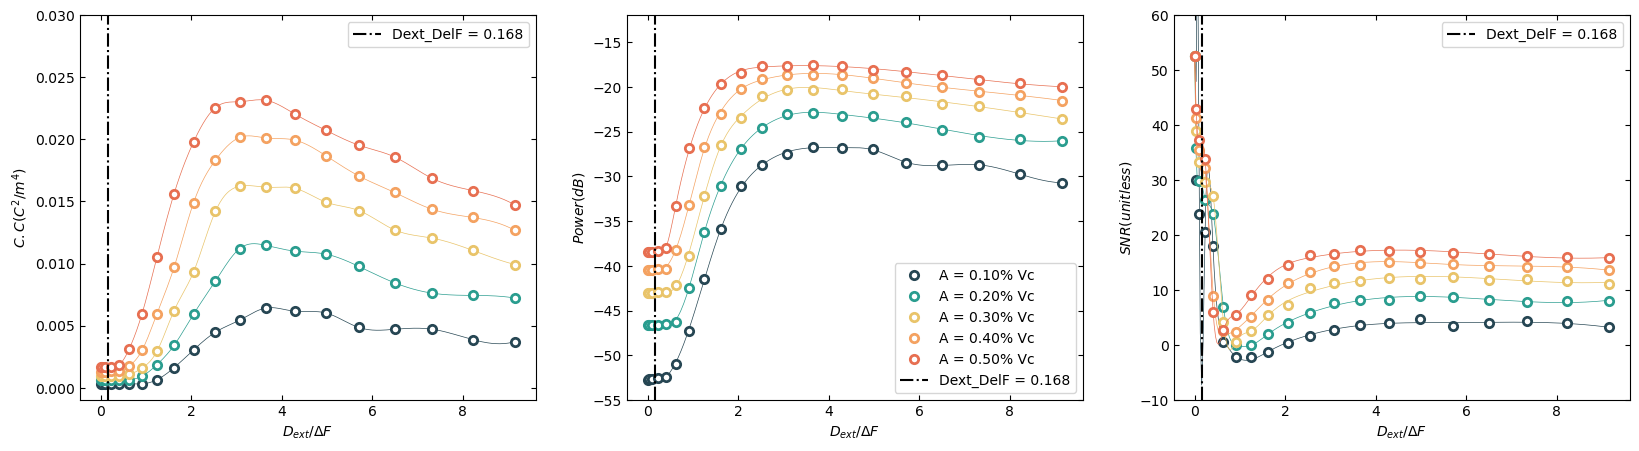

In [ ]:
lwth = 0.5
mwth = 2
ms = 6
clr = ["black", "blue", "red", "green", "yellow"]
clr = ["#1b263b", "#415a77", "#e63946", "#2a9d8f", "#f4a261"]
clr = ["#ff6b6b", "#4dabf7", "#51cf66", "#f2c94c", "#9b5de5"]
clr = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]


i = 0
styl = ["o", "o", "o", "o", "o"]

plt.figure(figsize=(20, 5))    
for i in range(len(Asig)):
    file_path = f'./sim_{id}/analysis/sr_metrics_f{fsig[0]}Hz_A{Asig[i]}V.json'
    sd_crt, bw_crt, Dext_delF, Dext_delF_crt, PSR, NF, SNR, COV = load_sr_metrics(file_path)
    sd_range = np.linspace(0.2,5,1000)
    Ktime = sr.calculate_kramer_curve(sd_range, 0, alpha, beta, rho, bw, tf, Af)
    target_time = 1/(2*fsig[0])
    interp_fn = interp1d(Ktime, sd_range, bounds_error=False, fill_value="extrapolate")
    sd_opt = interp_fn(target_time)
    bw = 1e6
    Dext_delF_opt = sr.Dext_delF(sd_opt, bw, alpha, beta, rho, tf, Af)[0]
    # print(f"Optimal SD: {sd_opt:.4f}, Dext/delF: {Dext_delF_opt:.4f}")
    # making spline fit for simulation
    # Create a dense x-axis for smooth plots
    Dext_delF_smooth = np.linspace(np.min(Dext_delF), np.max(Dext_delF), 300)

    # Spline interpolation for each curve
    psr_spline = UnivariateSpline(Dext_delF, 10*np.log10(PSR), s= 0.5)
    snr_spline = UnivariateSpline(Dext_delF, 10*np.log10(SNR), s=2)
    cov_spline = UnivariateSpline(Dext_delF, COV, s=0)

    # Evaluate spline on the smooth x-axis
    psr_smooth = psr_spline(Dext_delF_smooth)
    snr_smooth = snr_spline(Dext_delF_smooth)
    cov_smooth = cov_spline(Dext_delF_smooth)


    plt.subplot(1,3,1)
    plt.plot(Dext_delF_smooth, cov_smooth, "-", linewidth = lwth, c = clr[i])
    plt.plot(Dext_delF, COV, styl[i], linewidth = lwth, mew = mwth, markersize=ms, markerfacecolor='white', c = clr[i])
    
    plt.subplot(1,3,2)
    plt.plot(Dext_delF_smooth, psr_smooth, "-", linewidth = lwth, c = clr[i])
    plt.plot(Dext_delF, 10*np.log10(PSR), styl[i], linewidth = lwth, mew = mwth, markersize=ms, markerfacecolor='white',  c = clr[i], label = f"A = {Asig[i]/Vc:.2f}% Vc")
    
    plt.subplot(1,3,3)
    plt.plot(Dext_delF_smooth, snr_smooth, "-", linewidth = lwth, c = clr[i])
    plt.plot(Dext_delF, 10*np.log10(SNR), styl[i], linewidth = lwth, mew = mwth, markersize=ms, markerfacecolor='white', c = clr[i])
    
plt.subplot(1,3,1)
plt.xlabel("$D_{ext} / \Delta F$"); plt.ylabel("$C.C (C^2/m^4)$")
plt.axvline(x=Dext_delF_opt, color='black', linestyle='-.', label=f'Dext_DelF = {Dext_delF_opt:.3f}') # Draw vertical line at corresponding SD
plt.tick_params(axis='both', direction='in', top=True, right=True)
plt.ylim([-0.001, 0.03])
plt.legend()

plt.subplot(1,3,2)
plt.xlabel("$D_{ext} / \Delta F$"); plt.ylabel("$Power (dB)$")
plt.axvline(x=Dext_delF_opt, color='black', linestyle='-.', label=f'Dext_DelF = {Dext_delF_opt:.3f}') # Draw vertical line at corresponding SD
plt.tick_params(axis='both', direction='in', top=True, right=True  )
plt.ylim([-55, -12])
plt.legend()

plt.subplot(1,3,3)
plt.xlabel("$D_{ext} / \Delta F$"); plt.ylabel("$SNR (unitless)$")
plt.axvline(x=Dext_delF_opt, color='black', linestyle='-.', label=f'Dext_DelF = {Dext_delF_opt:.3f}') # Draw vertical line at corresponding SD
plt.tick_params(axis='both', direction='in', top=True, right=True  )
plt.ylim([-10, 60])
plt.legend()

